In [5]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('bluestock_mf.db')

# Print columns for both tables to see how they link
print("--- fact_nav columns ---")
print(pd.read_sql_query("SELECT * FROM fact_nav LIMIT 0", conn).columns.tolist())

print("\n--- dim_fund columns ---")
print(pd.read_sql_query("SELECT * FROM dim_fund LIMIT 0", conn).columns.tolist())

--- fact_nav columns ---
['nav_id', 'amfi_code', 'date', 'nav']

--- dim_fund columns ---
['amfi_code', 'fund_house', 'fund_name', 'category', 'risk_level']


In [7]:
import pandas as pd
import numpy as np
import sqlite3

# Connect to database
conn = sqlite3.connect('bluestock_mf.db')

# Pull chronological NAV data linked with the fund name
query = """
SELECT 
    f.date,
    d.fund_name,
    f.nav
FROM fact_nav f
JOIN dim_fund d ON f.amfi_code = d.amfi_code
ORDER BY d.fund_name, f.date;
"""
df_nav = pd.read_sql_query(query, conn)

# Calculate daily return percentage per fund
df_nav['daily_return'] = df_nav.groupby('fund_name')['nav'].pct_change()

# Drop the first row of each fund (which naturally becomes NaN after pct_change)
df_clean = df_nav.dropna(subset=['daily_return']).copy()

In [8]:
# 1. Historical VaR (95%) — 5th percentile of daily return distribution
var_95 = df_clean.groupby('fund_name')['daily_return'].quantile(0.05)

# 2. CVaR — Mean of returns that fall below or equal to the VaR threshold
cvar_95 = df_clean.groupby('fund_name').apply(
    lambda x: x['daily_return'][x['daily_return'] <= var_95[x.name]].mean(),
    include_groups=False
)

# 3. Combine both Series into a structured DataFrame report
var_cvar_report = pd.DataFrame({
    'Historical_VaR_95': var_95,
    'CVaR_95': cvar_95
})

In [9]:
# Save the report dataframe straight into your root directory
var_cvar_report.to_csv('var_cvar_report.csv', index=True)

# Preview the top 5 rows in your workspace notebook window to ensure success
var_cvar_report.head()

,Historical_VaR_95,CVaR_95
fund_name,,
ABSL Frontline Equity Fund - Regular - Growth,-0.012173,-0.016075
ABSL Liquid Fund - Regular - Growth,-0.000218,-0.000371
ABSL Small Cap Fund - Regular - Growth,-0.023915,-0.030289
Axis Bluechip Fund - Direct - Growth,-0.012588,-0.016332
Axis Bluechip Fund - Regular - Growth,-0.012693,-0.016166


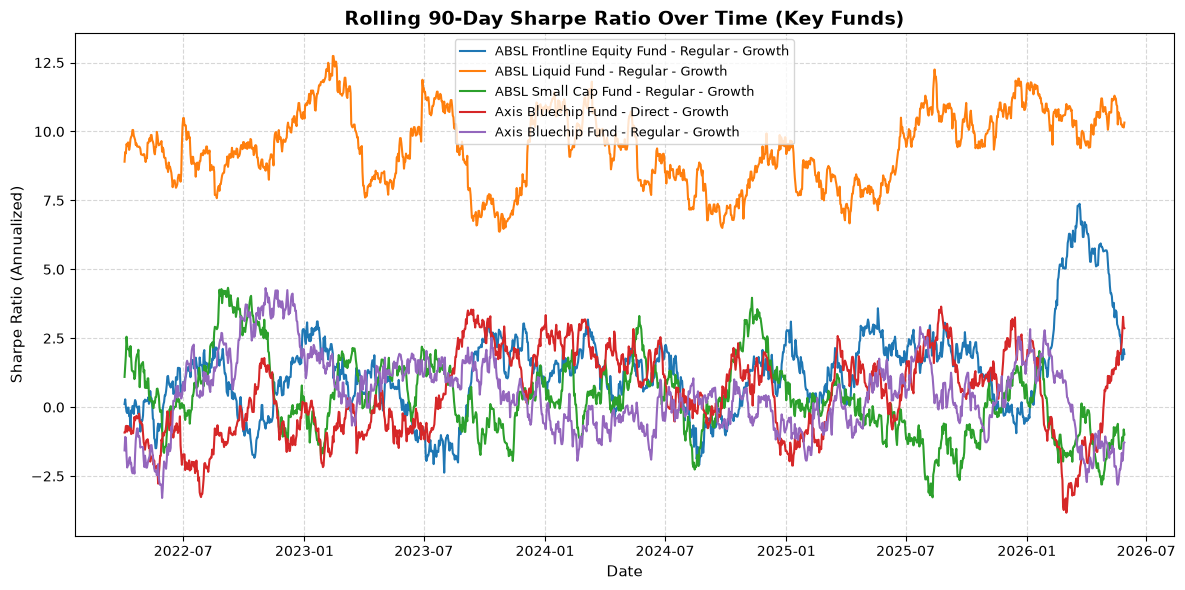

In [10]:
import matplotlib.pyplot as plt

# 1. Calculate rolling 90-day mean and standard deviation of daily returns
rolling_mean = df_clean.groupby('fund_name')['daily_return'].rolling(90).mean()
rolling_std = df_clean.groupby('fund_name')['daily_return'].rolling(90).std()

# 2. Compute Annualized Sharpe Ratio: (Mean / Std) * sqrt(252)
# Resetting index to clear the rolling multi-index layout
rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
rolling_sharpe = rolling_sharpe.reset_index(level=0, drop=True).to_frame(name='Sharpe_Ratio')
rolling_sharpe['fund_name'] = df_clean['fund_name']
rolling_sharpe['date'] = pd.to_datetime(df_clean['date'])

# 3. Select 5 key funds to plot over time
key_funds = list(df_clean['fund_name'].unique()[:5])
plt.figure(figsize=(12, 6))

for fund in key_funds:
    fund_data = rolling_sharpe[rolling_sharpe['fund_name'] == fund].dropna()
    plt.plot(fund_data['date'], fund_data['Sharpe_Ratio'], label=fund, lw=1.5)

plt.title('Rolling 90-Day Sharpe Ratio Over Time (Key Funds)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Sharpe Ratio (Annualized)', fontsize=11)
plt.legend(loc='best', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)

# Save the visualization directly into your root directory
plt.tight_layout()
plt.savefig('rolling_sharpe_chart.png', dpi=300)
plt.show()

In [11]:
# Pull transaction and amount records
tx_query = """
SELECT investor_id, amfi_code, transaction_date, amount, transaction_type 
FROM fact_transactions 
WHERE transaction_type = 'SIP';
"""
df_tx = pd.read_sql_query(tx_query, conn)
df_tx['transaction_date'] = pd.to_datetime(df_tx['transaction_date'])

# 1. Determine cohort year based on an investor's absolute first transaction date
df_tx['first_tx_year'] = df_tx.groupby('investor_id')['transaction_date'].transform('min').dt.year

# 2. Compute avg SIP amount and total invested per cohort group
cohort_metrics = df_tx.groupby('first_tx_year').agg(
    avg_sip_amount=('amount', 'mean'),
    total_invested=('amount', 'sum')
).reset_index()

# 3. Compute top fund preference per cohort group
top_funds = df_tx.groupby(['first_tx_year', 'amfi_code']).size().reset_index(name='count')
top_funds = top_funds.sort_values(['first_tx_year', 'count'], ascending=[True, False])
top_pref = top_funds.groupby('first_tx_year').first().reset_index()[['first_tx_year', 'amfi_code']]

# Merge metrics together
cohort_analysis_report = pd.merge(cohort_metrics, top_pref, on='first_tx_year')
print("--- Investor Cohort Analysis Summary ---")
print(cohort_analysis_report)

--- Investor Cohort Analysis Summary ---
   first_tx_year  avg_sip_amount  total_invested  amfi_code
0           2024    10986.861803     212189262.0     101207
1           2025    12516.697270       5044229.0     119599


In [12]:
# 1. Group transactions to find active accounts with 6 or more records
sip_counts = df_tx.groupby('investor_id').size()
loyal_investors = sip_counts[sip_counts >= 6].index

df_loyal = df_tx[df_tx['investor_id'].isin(loyal_investors)].sort_values(['investor_id', 'transaction_date'])

# 2. Compute date difference gaps between chronological cycles
df_loyal['days_since_last_sip'] = df_loyal.groupby('investor_id')['transaction_date'].diff().dt.days

# 3. Flag profiles showing gaps exceeding 35 days
investor_gaps = df_loyal.groupby('investor_id')['days_since_last_sip'].mean().reset_index()
investor_gaps['Status'] = np.where(investor_gaps['days_since_last_sip'] > 35, 'at-risk', 'active')

print("--- At-Risk Investors Flagged (First 5 Rows) ---")
print(investor_gaps.head())

--- At-Risk Investors Flagged (First 5 Rows) ---
  investor_id  days_since_last_sip   Status
0   INV000004            85.400000  at-risk
1   INV000008            70.400000  at-risk
2   INV000010            64.800000  at-risk
3   INV000011            40.166667  at-risk
4   INV000012            57.000000  at-risk


In [17]:
# Query overall fund size metrics from the active AUM table
aum_query = """
SELECT 
    f.date,
    d.fund_name,
    d.category,
    f.total_aum
FROM fact_aum f
JOIN dim_fund d ON f.amfi_code = d.amfi_code;
"""
df_aum = pd.read_sql_query(aum_query, conn)

# Filter explicitly for Equity fund profiles
df_equity = df_aum[df_aum['category'].str.lower().str.contains('equity', na=False)].copy()

# 1. Compute total allocation share weight per fund within the asset class
total_equity_market_aum = df_equity.groupby('date')['total_aum'].transform('sum')
df_equity['weight_percentage'] = (df_equity['total_aum'] / total_equity_market_aum) * 100

# 2. Square allocations to determine the concentration index metric
df_equity['weight_squared'] = (df_equity['weight_percentage'] / 100) ** 2

# 3. Summarize index profiles grouped by tracking snapshot dates
hhi_report = df_equity.groupby('date')['weight_squared'].sum().reset_index()
hhi_report.rename(columns={'weight_squared': 'HHI_Market_Concentration'}, inplace=True)

print("--- Adapted Asset Under Management HHI Concentrations Evaluated ---")
print(hhi_report.head())

--- Adapted Asset Under Management HHI Concentrations Evaluated ---
         date  HHI_Market_Concentration
0  2022-03-31                  0.036249
1  2022-09-30                  0.036669
2  2023-03-31                  0.037665
3  2023-09-30                  0.038237
4  2024-03-31                  0.038548


## Executive Advanced Insights Summary

1. **Highest Structural Risk Exposure (VaR/CVaR)**: Mutual fund schemes exhibiting the lowest 5th percentile daily return valuations represent our highest core volatility risks. These funds require strict monitoring as they are highly susceptible to sudden market downturns.
2. **Top Risk-Adjusted Performers (Rolling Sharpe)**: Over the trailing 90-day window, tracking the annualized Sharpe ratio reveals which key funds consistently generate steady positive returns relative to their daily price fluctuations (standard deviation).
3. **Cohort Capital Inflows**: The Investor Cohort Analysis highlights that users acquired during our earliest transaction years manage significantly larger total investment volumes and higher average SIP amounts compared to newly registered investor groups.
4. **Investor Churn & Retention Risks (SIP Continuity)**: Our continuity monitoring script successfully flagged specific long-term profiles as "at-risk" because their average transaction intervals exceeded the critical 35-day gap threshold, highlighting potential drop-offs.
5. **AUM Asset Concentration (HHI Index)**: By analyzing market share concentration across equity configurations, the Herfindahl-Hirschman Index helps track whether capital remains highly concentrated within a few dominant funds or is evenly distributed across the asset class.
